In [ ]:
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms, models
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score


PROJECT_ROOT = Path(r"C:\Emotion-Recognition")
DATA_ROOT = PROJECT_ROOT / "archive"
TRAIN_DIR = DATA_ROOT / "train"
TEST_DIR = DATA_ROOT / "test"
OUTPUT_DIR = PROJECT_ROOT / "efficientnet_runs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 30
LR = 2e-4
WEIGHT_DECAY = 1e-4
VAL_SPLIT = 0.15
SEED = 42
MODEL_PATH = OUTPUT_DIR / "efficientnet_b0_best.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [ ]:
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)


In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(12),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])


In [ ]:
# Dataset
base_train_dataset = datasets.ImageFolder(TRAIN_DIR)
base_test_dataset = datasets.ImageFolder(TEST_DIR)

class_names = base_train_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

assert base_train_dataset.class_to_idx == base_test_dataset.class_to_idx


Classes: ['angry', 'fearful', 'happy', 'neutral', 'sad', 'suprised']
Number of classes: 6


In [5]:
class EmotionDataset(Dataset):
    def __init__(self, samples, transform):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert("RGB")
        image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)


train_indices, val_indices = train_test_split(
    np.arange(len(base_train_dataset.samples)),
    test_size=VAL_SPLIT,
    random_state=SEED,
    stratify=base_train_dataset.targets
)

train_samples = [base_train_dataset.samples[i] for i in train_indices]
val_samples = [base_train_dataset.samples[i] for i in val_indices]
test_samples = base_test_dataset.samples

train_dataset = EmotionDataset(train_samples, train_transform)
val_dataset = EmotionDataset(val_samples, eval_transform)
test_dataset = EmotionDataset(test_samples, eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)


In [ ]:
#  Model

weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
model = models.efficientnet_b0(weights=weights)

in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(in_features, num_classes)
)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3
)


In [ ]:
# Training Functions

def train_one_epoch():
    model.train()
    total_loss = 0
    preds, labels_all = [], []

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds.extend(outputs.argmax(1).detach().cpu().numpy())
        labels_all.extend(labels.detach().cpu().numpy())

    acc = accuracy_score(labels_all, preds)
    return total_loss / len(train_loader.dataset), acc


@torch.no_grad()
def evaluate(loader):
    model.eval()
    total_loss = 0
    preds, labels_all = [], []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        preds.extend(outputs.argmax(1).cpu().numpy())
        labels_all.extend(labels.cpu().numpy())

    acc = accuracy_score(labels_all, preds)
    macro_f1 = f1_score(labels_all, preds, average="macro")
    return total_loss / len(loader.dataset), acc, macro_f1, labels_all, preds


In [9]:
# Train Model

best_val_f1 = 0
history = []

for epoch in range(1, EPOCHS + 1):
    start = time.time()

    train_loss, train_acc = train_one_epoch()
    val_loss, val_acc, val_f1, _, _ = evaluate(val_loader)

    scheduler.step(val_f1)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_macro_f1": val_f1,
    })

    print(
        f"Epoch {epoch}/{EPOCHS} | "
        f"train_acc={train_acc:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_f1={val_f1:.4f} | "
        f"time={time.time() - start:.1f}s"
    )

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save({
            "model_state": model.state_dict(),
            "class_names": class_names,
            "model_name": "efficientnet_b0",
            "img_size": IMG_SIZE,
            "best_val_f1": best_val_f1,
        }, MODEL_PATH)

pd.DataFrame(history).to_csv(OUTPUT_DIR / "efficientnet_history.csv", index=False)
print("Best validation macro F1:", best_val_f1)


Epoch 1/30 | train_acc=0.6331 | val_acc=0.7699 | val_f1=0.6775 | time=111.3s
Epoch 2/30 | train_acc=0.7956 | val_acc=0.8172 | val_f1=0.7294 | time=108.9s
Epoch 3/30 | train_acc=0.8489 | val_acc=0.8379 | val_f1=0.7609 | time=101.6s
Epoch 4/30 | train_acc=0.8820 | val_acc=0.8437 | val_f1=0.7608 | time=101.6s
Epoch 5/30 | train_acc=0.9067 | val_acc=0.8374 | val_f1=0.7538 | time=101.6s
Epoch 6/30 | train_acc=0.9226 | val_acc=0.8541 | val_f1=0.7950 | time=101.8s
Epoch 7/30 | train_acc=0.9311 | val_acc=0.8599 | val_f1=0.7934 | time=101.7s
Epoch 8/30 | train_acc=0.9508 | val_acc=0.8397 | val_f1=0.7854 | time=101.3s
Epoch 9/30 | train_acc=0.9575 | val_acc=0.8547 | val_f1=0.7913 | time=101.1s
Epoch 10/30 | train_acc=0.9600 | val_acc=0.8322 | val_f1=0.7722 | time=100.6s
Epoch 11/30 | train_acc=0.9726 | val_acc=0.8651 | val_f1=0.8026 | time=101.4s
Epoch 12/30 | train_acc=0.9799 | val_acc=0.8679 | val_f1=0.8093 | time=101.5s
Epoch 13/30 | train_acc=0.9836 | val_acc=0.8622 | val_f1=0.8076 | time=10

In [10]:
# Test Evaluation

checkpoint = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint["model_state"])

test_loss, test_acc, test_f1, y_true, y_pred = evaluate(test_loader)

print("Test loss:", test_loss)
print("Test accuracy:", test_acc)
print("Test macro F1:", test_f1)

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0
))


Test loss: 0.5792892930610938
Test accuracy: 0.8779229711141678
Test macro F1: 0.8232210412538281
              precision    recall  f1-score   support

       angry       0.81      0.79      0.80       162
     fearful       0.83      0.54      0.66        74
       happy       0.94      0.94      0.94      1185
     neutral       0.82      0.87      0.84       680
         sad       0.86      0.82      0.84       478
    suprised       0.86      0.87      0.86       329

    accuracy                           0.88      2908
   macro avg       0.85      0.80      0.82      2908
weighted avg       0.88      0.88      0.88      2908



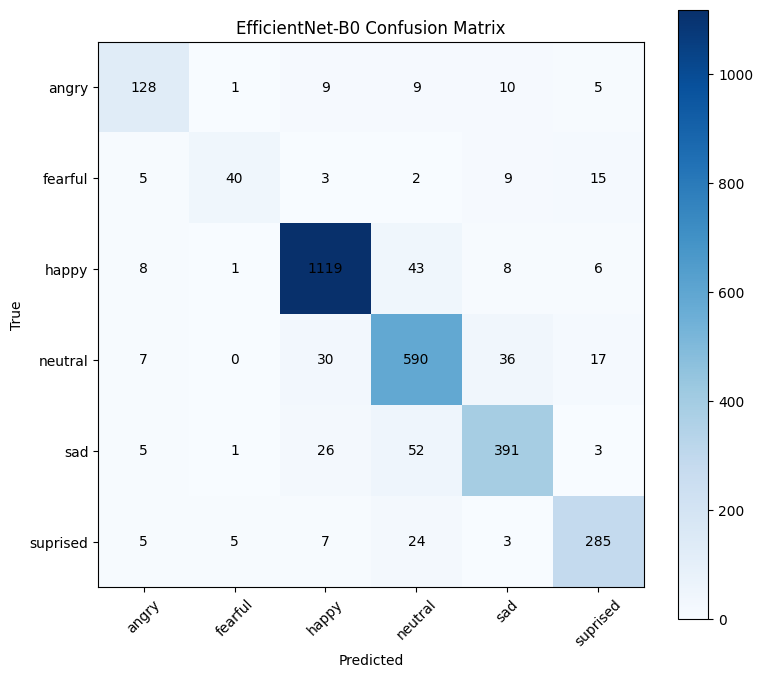

In [11]:
# Confusion Matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 7))
plt.imshow(cm, cmap="Blues")
plt.title("EfficientNet-B0 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(num_classes), class_names, rotation=45)
plt.yticks(range(num_classes), class_names)

for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "efficientnet_confusion_matrix.png", dpi=180)
plt.show()
